In [ ]:
# stdlib pathlib (filesystem paths)
from pathlib import Path

# src/utils/pathing.py
from src.utils.pathing import ensure_repo_root_on_sys_path  # src/utils/pathing.py

ensure_repo_root_on_sys_path(Path.cwd())

# 20. Ensemble Learning: Random Forest

## Algorithm Category
**Type**: Ensemble Learning - Classification/Regression  
**Complexity**: Medium  
**Use Case**: Ensemble of decision trees with bagging and feature randomness

## Learning Objectives

By the end of this notebook, you will be able to:
- Understand the Random Forest algorithm and ensemble learning principles
- Implement Random Forest for classification and regression
- Understand bagging, feature sampling, and out-of-bag evaluation
- Extract and interpret feature importance
- Tune hyperparameters (n_estimators, max_depth, max_features)
- Apply Random Forest to real-world problems

## Historical Context

Random Forest was developed by Leo Breiman in 2001:
- Breiman, L. (2001): "Random Forests"
- Combines bagging (Bootstrap Aggregating) with random feature selection
- Built on earlier work: Decision Trees (Breiman et al., 1984) and Bagging (Breiman, 1996)

**Key Papers/References:**
- Breiman, L. (2001). "Random Forests"
- Breiman, L. (1996). "Bagging Predictors"
- Ho, T.K. (1995). "Random Decision Forests"

## When to Use Random Forest

Random Forest is appropriate when:
- You need high accuracy with minimal tuning
- Working with mixed data types (numerical and categorical)
- Feature importance interpretation is needed
- Handling missing values and outliers
- Large datasets with many features
- Non-linear relationships in data

## Theory & Mechanics

### Mathematical Foundation

Random Forest combines multiple decision trees using bagging and random feature selection.

**Bagging (Bootstrap Aggregating):**
- Train each tree on a bootstrap sample (random sampling with replacement)
- Average predictions (regression) or majority vote (classification)

**Random Feature Selection:**
- At each split, consider only a random subset of features
- Typically: $\sqrt{n}$ features for classification, $n/3$ for regression

**Final Prediction:**
- **Classification**: $\hat{y} = \text{mode}(\{\hat{y}_1, \hat{y}_2, ..., \hat{y}_T\})$
- **Regression**: $\hat{y} = \frac{1}{T}\sum_{i=1}^{T}\hat{y}_i$

Where $T$ is the number of trees.

**Out-of-Bag (OOB) Score:**
- Each tree is trained on ~63% of data (bootstrap sample)
- Remaining ~37% is "out-of-bag" and can be used for validation
- OOB score estimates generalization without separate validation set

### How It Works

1. **Bootstrap Sampling**: Create T bootstrap samples from training data
2. **Train Trees**: Train a decision tree on each bootstrap sample
3. **Random Features**: At each split, consider random subset of features
4. **Aggregate**: Combine predictions from all trees
5. **OOB Evaluation**: Use out-of-bag samples for validation

### Key Hyperparameters

- **n_estimators**: Number of trees (more = better but slower)
- **max_depth**: Maximum depth of trees (None = unlimited)
- **max_features**: Number of features to consider for best split
- **min_samples_split**: Minimum samples required to split a node
- **min_samples_leaf**: Minimum samples required in a leaf node
- **bootstrap**: Whether to use bootstrap sampling (default: True)
- **oob_score**: Whether to calculate out-of-bag score (default: False)

### Advantages

- Reduces overfitting compared to single decision tree
- Handles missing values and outliers well
- Provides feature importance
- No feature scaling required
- Works well with default parameters

### Limitations

- Less interpretable than single decision tree
- Can be memory intensive (stores all trees)
- Slower prediction than linear models
- May not perform well on very high-dimensional sparse data


## Implementation

Let's implement Random Forest for both classification and regression.


In [1]:
# ============================================
# IMPORTING LIBRARIES: Setting Up Our Tools
# ============================================

# Core data science libraries
import numpy as np  # NumPy: Numerical computing (arrays, math operations)
import pandas as pd  # Pandas: Data manipulation (DataFrames, data analysis)
import matplotlib.pyplot as plt  # Matplotlib: Plotting and visualization

# Python stdlib (path handling for imports)
from pathlib import Path  # stdlib pathlib (filesystem paths)
import sys  # stdlib sys (Python path management)

# Add repo root to PYTHONPATH so `import src...` works from notebooks.
repo_root_candidate = Path.cwd().resolve()
while repo_root_candidate != repo_root_candidate.parent and not (repo_root_candidate / "src").is_dir():
    repo_root_candidate = repo_root_candidate.parent
if not (repo_root_candidate / "src").is_dir():
    raise RuntimeError("Repository root not found. Expected a parent folder with 'src'.")
if str(repo_root_candidate) not in sys.path:
    sys.path.insert(0, str(repo_root_candidate))

# src/utils/pathing.py
from src.utils.pathing import ensure_repo_root_on_sys_path

project_root = ensure_repo_root_on_sys_path(Path.cwd())

# Scikit-learn: Machine learning library
# sklearn.datasets (scikit-learn package)
from sklearn.datasets import (
    load_iris,  # Iris flower classification dataset
    load_diabetes,  # Diabetes regression dataset
    load_breast_cancer  # Breast cancer classification dataset
)
# sklearn.ensemble (scikit-learn package)
from sklearn.ensemble import (
    RandomForestClassifier,  # Random Forest for classification
    RandomForestRegressor  # Random Forest for regression
)
# sklearn.model_selection (scikit-learn package)
from sklearn.model_selection import (
    train_test_split,  # Split data into train/test sets
    cross_val_score,  # Cross-validation scoring
    GridSearchCV  # Hyperparameter tuning
)
# sklearn.metrics (scikit-learn package)
from sklearn.metrics import (
    accuracy_score,  # Calculate accuracy (for classification)
    mean_squared_error,  # Calculate MSE (for regression)
    mean_absolute_error,  # Calculate MAE (for regression)
    r2_score  # Calculate R^2 (variance explained)
)
# sklearn.tree (scikit-learn package)
from sklearn.tree import plot_tree  # Visualize individual decision trees

# ============================================
# IMPORTING OUR HELPER FUNCTIONS
# ============================================

# Our custom utility functions (organized in src/ directory)
# src/models/supervised.py
from src.models.supervised import (
    split_data,  # Split data into train/test sets
    evaluate_classifier,  # Evaluate classification models
    evaluate_regressor  # Evaluate regression models
)
# src/models/classification.py
from src.models.classification import (
    calculate_classification_metrics,  # Calculate precision, recall, F1, etc.
    plot_confusion_matrix  # Visualize confusion matrix
)
# src/models/ensemble.py
from src.models.ensemble import (
    extract_feature_importance,  # Extract feature importance from ensemble
    plot_feature_importance,  # Visualize feature importance
    calculate_oob_error  # Calculate out-of-bag error
)
# src/utils/benchmarking.py
from src.utils.benchmarking import benchmark_model_training  # Measure training time
# src/utils/traceability.py
from src.utils.traceability import save_traceability_data  # Save model information
# src/utils/validation.py
from src.utils.validation import (
    validate_model_output,  # Check if predictions are valid
    check_cross_validation_stability  # Check CV stability
)

print("Libraries imported successfully!")  # Confirm all imports worked


Libraries imported successfully!


In [2]:
# ============================================
# LOADING THE DATASET: Breast Cancer Classification
# ============================================

# load_breast_cancer() loads the Breast Cancer Wisconsin dataset from scikit-learn
# This is a binary classification problem: predict if tumor is malignant (1) or benign (0)
cancer = load_breast_cancer()  # Returns a Bunch object with data, target, feature_names

# X = Features (inputs): Medical measurements of breast tumors
# cancer.data contains feature values (569 samples × 30 features)
# We convert to DataFrame for easier manipulation
X = pd.DataFrame(cancer.data, columns=cancer.feature_names)
# Features include: mean radius, mean texture, mean perimeter, mean area, etc. (30 total)

# y = Target (output): Tumor type (what we want to predict)
# cancer.target contains class labels (0 = benign, 1 = malignant)
y = pd.Series(cancer.target, name='Target')
# 0 = benign (non-cancerous), 1 = malignant (cancerous)

print(f"Dataset Shape: {X.shape}")  # Output: (569, 30) - 569 patients, 30 features
print(f"Classes: {cancer.target_names.tolist()}")  # Output: ['malignant', 'benign']

# ============================================
# TRAIN/TEST SPLIT: Separating Data
# ============================================

# Note: Random Forest doesn't require feature scaling (unlike SVM or K-NN)
# Decision trees are scale-invariant (splits are based on comparisons, not distances)

# split_data() randomly splits data into training (80%) and test (20%) sets
# test_size=0.2 means 20% for testing, 80% for training
# random_state=42 ensures same split every time (reproducibility)
X_train, X_test, y_train, y_test = split_data(X, y, test_size=0.2, random_state=42)
# X_train: 80% of samples for training
# X_test: 20% of samples for testing
# y_train: Target values for training samples
# y_test: Target values for test samples (ground truth)

# ============================================
# MODEL CREATION: Random Forest Classifier
# ============================================

# Create a RandomForestClassifier model
# Random Forest combines multiple decision trees using bagging and random feature selection

# RandomForestClassifier parameters:
# n_estimators=100: Number of trees in the forest
#   - More trees = better performance but slower
#   - Typical values: 50-200 (100 is a good default)
#
# max_depth=10: Maximum depth of each tree
#   - Limits tree growth to prevent overfitting
#   - None = unlimited depth (may overfit)
#   - Smaller = simpler trees, may underfit
#
# random_state=42: Ensures reproducible results
#
# oob_score=True: Calculate out-of-bag score
#   - Each tree is trained on ~63% of data (bootstrap sample)
#   - Remaining ~37% is "out-of-bag" and can be used for validation
#   - OOB score estimates generalization without separate validation set
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, oob_score=True)

# ============================================
# MODEL TRAINING: Learning from Data
# ============================================

# .fit() trains the Random Forest
# The algorithm:
# 1. Creates 100 bootstrap samples (random sampling with replacement)
# 2. Trains a decision tree on each bootstrap sample
# 3. At each split, considers only random subset of features
# 4. Combines predictions from all trees (majority vote for classification)
model.fit(X_train, y_train)  # Train the model

print("\nRandom Forest Classifier:")
print(f"Number of trees: {model.n_estimators}")  # Number of trees (100)

# Out-of-bag score: Accuracy on samples not used to train each tree
# This is a built-in validation metric (no need for separate validation set!)
print(f"Out-of-bag score: {model.oob_score_:.3f}")  # OOB accuracy
# OOB score is a good estimate of generalization performance

# ============================================
# MAKING PREDICTIONS
# ============================================

# .predict() makes predictions by:
# 1. Each tree makes a prediction
# 2. For classification: majority vote (most common prediction)
# 3. For regression: average of all tree predictions
y_pred = model.predict(X_test)  # Class predictions (0 or 1)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)  # Compare predictions to true labels
print(f"\nTest Accuracy: {accuracy:.3f}")  # Display accuracy

# ============================================
# EVALUATING MODEL PERFORMANCE
# ============================================

# Evaluate with helper function
results = evaluate_classifier(model, X_test, y_test)
# Returns dictionary with accuracy and other metrics

# Calculate detailed classification metrics
metrics = calculate_classification_metrics(y_test.values, y_pred)
# Returns dictionary with: accuracy, precision, recall, F1

print(f"Precision: {metrics['precision']:.3f}, Recall: {metrics['recall']:.3f}, F1: {metrics['f1_score']:.3f}")
# Precision: Of predicted positives, how many were actually positive
# Recall: Of actual positives, how many did we catch
# F1: Harmonic mean of precision and recall (balances both)


Dataset Shape: (569, 30)
Classes: ['malignant', 'benign']

Random Forest Classifier:
Number of trees: 100
Out-of-bag score: 0.956

Test Accuracy: 0.965
Precision: 0.965, Recall: 0.965, F1: 0.965


## Feature Importance

Let's extract and visualize feature importance.


Top 10 Most Important Features:
                 feature  importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001
22       worst perimeter    0.067115
2         mean perimeter    0.053270
0            mean radius    0.048703
3              mean area    0.047555
26       worst concavity    0.031802


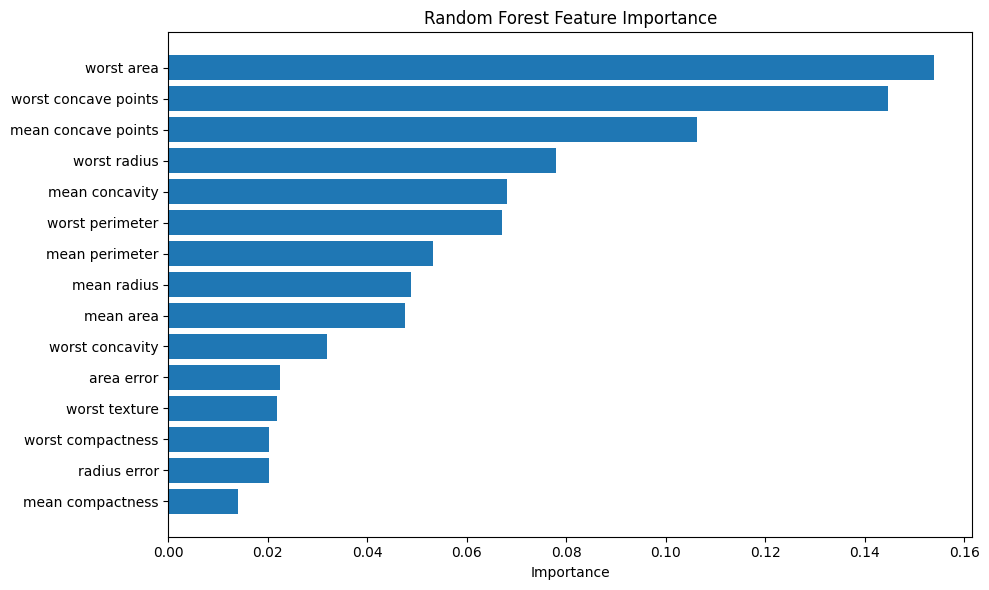

In [3]:
# ============================================
# FEATURE IMPORTANCE: Which Features Matter Most?
# ============================================

# Random Forest provides feature importance based on:
# 1. How often a feature is used for splitting
# 2. How much it reduces impurity (Gini/entropy) when used
# Higher importance = feature is more useful for predictions

# extract_feature_importance() extracts and organizes feature importance
feature_importance = extract_feature_importance(
    model,  # The trained Random Forest (has .feature_importances_ attribute)
    feature_names=X.columns.tolist()  # List of feature names
)
# Returns DataFrame with features sorted by importance (highest first)

print("Top 10 Most Important Features:")
# Display the most important features
print(feature_importance.head(10))

# Visualize feature importance
plot_feature_importance(feature_importance, top_n=15, title="Random Forest Feature Importance")


## Validation & Testing

Let's validate the model and analyze out-of-bag error.


In [4]:
# Validation 1: Out-of-bag error
oob_error = calculate_oob_error(model)
if oob_error is not None:
    print(f"Out-of-Bag Error: {oob_error:.3f}")
    print(f"Out-of-Bag Accuracy: {1 - oob_error:.3f}")

# Validation 2: Cross-validation
cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
cv_mean = cv_scores.mean()
cv_std = cv_scores.std()

print(f"\nCross-Validation Results (5-fold):")
print(f"  Mean Accuracy: {cv_mean:.3f} (+/- {cv_std:.3f})")

stability = check_cross_validation_stability(cv_scores, threshold=0.1)
print(f"  Is Stable: {stability['is_stable']}")

# Validation 3: Check model output
validation_result = validate_model_output(y_pred, y_test.values, task_type='classification')
assert validation_result['valid'], "Invalid predictions!"
assert accuracy > 0.5, "Accuracy should be better than random!"
print("\n✓ Validation checks passed")


Out-of-Bag Error: 0.044
Out-of-Bag Accuracy: 0.956

Cross-Validation Results (5-fold):
  Mean Accuracy: 0.956 (+/- 0.023)
  Is Stable: True

✓ Validation checks passed


## Effect of Number of Trees

Let's see how performance changes with the number of trees.


/home/goble54/spark-dev-workspace/VSP-AI-ML-Training/.venv/lib/python3.12/site-packages/sklearn/ensemble/_forest.py:611: UserWarning: Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.
  warn(


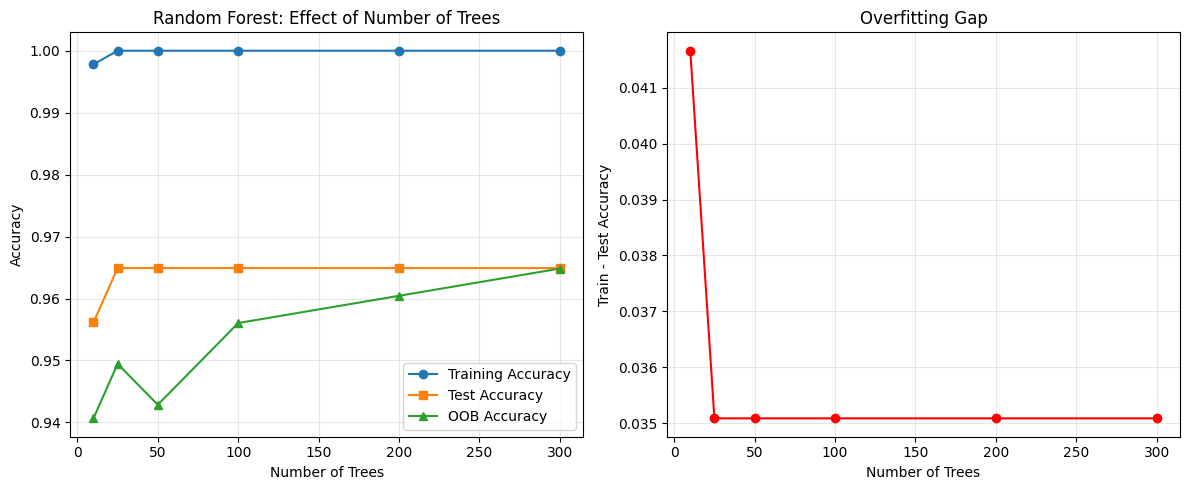

Best number of trees (by test accuracy): 25


In [5]:
# Test different numbers of trees
n_trees_range = [10, 25, 50, 100, 200, 300]
train_scores = []
test_scores = []
oob_scores = []

for n_trees in n_trees_range:
    rf = RandomForestClassifier(n_estimators=n_trees, max_depth=10, 
                               random_state=42, oob_score=True, n_jobs=-1)
    rf.fit(X_train, y_train)
    
    train_scores.append(accuracy_score(y_train, rf.predict(X_train)))
    test_scores.append(accuracy_score(y_test, rf.predict(X_test)))
    oob_scores.append(rf.oob_score_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(n_trees_range, train_scores, 'o-', label='Training Accuracy')
plt.plot(n_trees_range, test_scores, 's-', label='Test Accuracy')
plt.plot(n_trees_range, oob_scores, '^-', label='OOB Accuracy')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.title('Random Forest: Effect of Number of Trees')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_trees_range, [t - s for t, s in zip(train_scores, test_scores)], 'o-', color='red')
plt.xlabel('Number of Trees')
plt.ylabel('Train - Test Accuracy')
plt.title('Overfitting Gap')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Best number of trees (by test accuracy): {n_trees_range[np.argmax(test_scores)]}")


## Regression Example

Let's apply Random Forest to regression using the diabetes dataset. We'll build this in steps so you can see what each piece adds:

### Goals
- Establish a **baseline** (mean predictor) so we know what “good” looks like.
- Train a **RandomForestRegressor** and measure multiple metrics (RMSE, MAE, R²).
- Use **cross-validation** for more reliable performance estimates.
- Run **error analysis** with residual plots to see where the model struggles.
- Inspect **feature importance** to interpret the model.
- Explore **model size effects** (n_estimators sweep + OOB curve).
- Do a **light hyperparameter tune** and compare to the default model.

### Evaluation plan
- **RMSE** (penalizes larger errors)
- **MAE** (average absolute error, easier to interpret)
- **R²** (variance explained)

> Note: Random Forest uses internal out-of-bag (OOB) samples as a built-in validation set when `oob_score=True`.


Regression dataset overview:
  X shape: (442, 10)
  y shape: (442,)
  Missing values in X: 0
  Target stats -> mean: 152.13, std: 77.09

Baseline (Mean Predictor):
  RMSE: 73.222
  MAE:  64.006
  R^2:  -0.012

Random Forest Regression (Default):
  RMSE: 54.818
  MAE:  44.612
  R^2:  0.433
  OOB R^2: 0.445

Cross-Validation (5-fold):
  RMSE: 57.717 ± 2.352
  MAE:  46.986 ± 2.280
  R^2:  0.424 ± 0.053


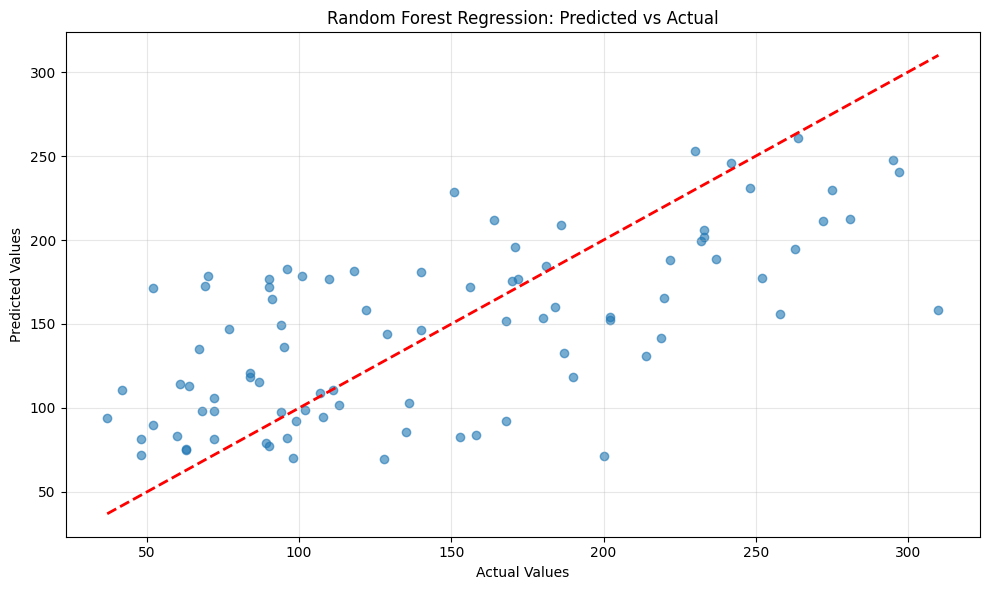

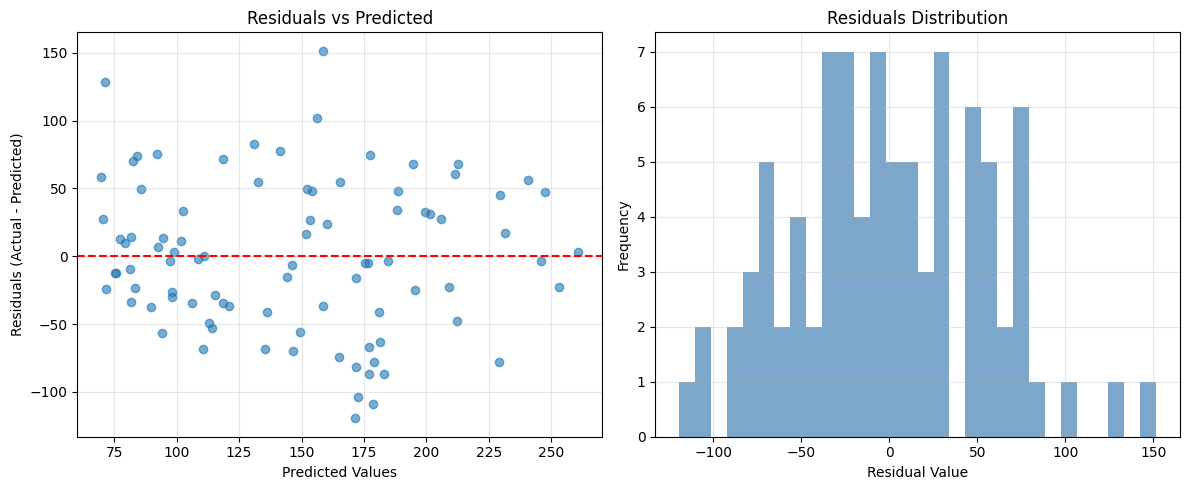

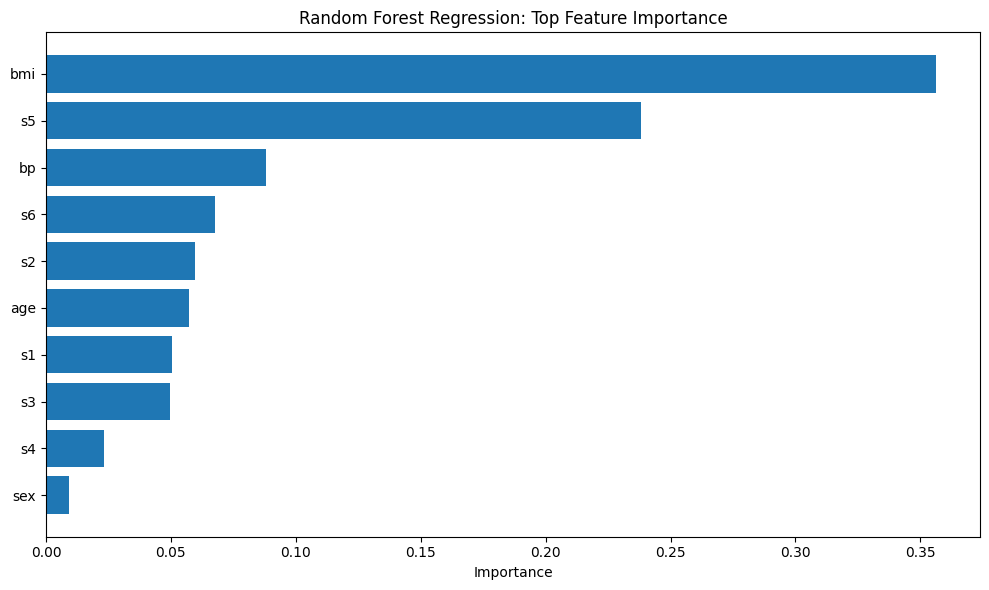

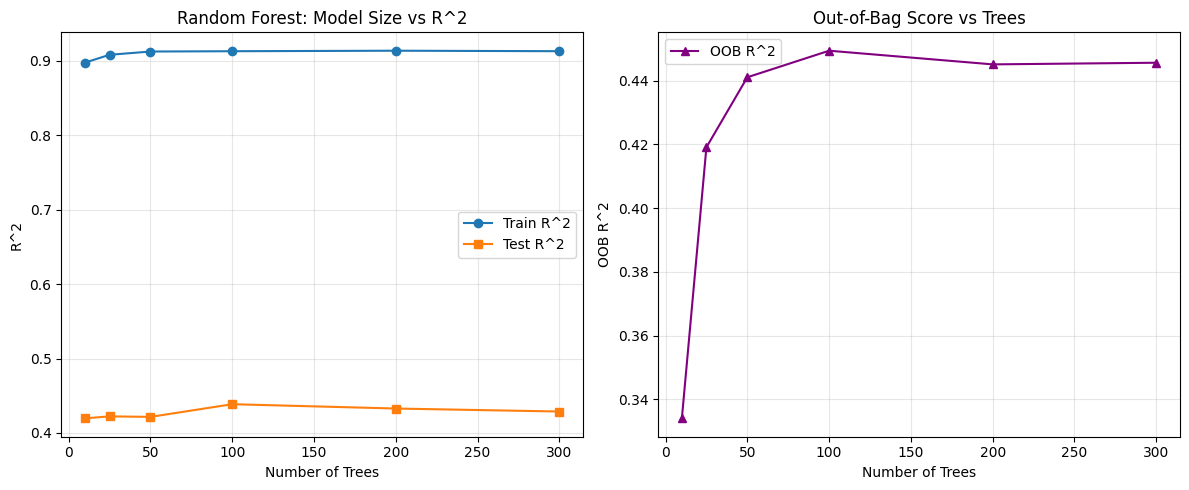


Best Regression Hyperparameters:
{'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}

Model Comparison (Lower RMSE/MAE is better, Higher R^2 is better):
                     Model       RMSE        MAE       R^2
0          Baseline (Mean)  73.222493  64.006461 -0.011963
1  Random Forest (Default)  54.817563  44.612078  0.432828
2    Random Forest (Tuned)  53.866492  43.443597  0.452338


In [6]:
# Regression Example: Diabetes dataset
# sklearn.datasets (scikit-learn package)
diabetes = load_diabetes()
X_reg = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
y_reg = pd.Series(diabetes.target, name='Target')

print("Regression dataset overview:")
print(f"  X shape: {X_reg.shape}")
print(f"  y shape: {y_reg.shape}")
print(f"  Missing values in X: {X_reg.isna().sum().sum()}")
print(f"  Target stats -> mean: {y_reg.mean():.2f}, std: {y_reg.std():.2f}")

# Split data into train/test sets
X_reg_train, X_reg_test, y_reg_train, y_reg_test = split_data(
    X_reg, y_reg, test_size=0.2, random_state=42
)

# --------------------------------------------
# 1) Baseline: Mean Predictor
# --------------------------------------------
# Baseline predicts the mean of the training target for every sample.
# This is a simple reference point to beat.
baseline_value = y_reg_train.mean()
baseline_pred = np.full(shape=len(y_reg_test), fill_value=baseline_value, dtype=float)

baseline_rmse = np.sqrt(mean_squared_error(y_reg_test, baseline_pred))
baseline_mae = mean_absolute_error(y_reg_test, baseline_pred)
baseline_r2 = r2_score(y_reg_test, baseline_pred)

print("\nBaseline (Mean Predictor):")
print(f"  RMSE: {baseline_rmse:.3f}")
print(f"  MAE:  {baseline_mae:.3f}")
print(f"  R^2:  {baseline_r2:.3f}")

# --------------------------------------------
# 2) Train Default Random Forest Regressor
# --------------------------------------------
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf_reg.fit(X_reg_train, y_reg_train)

y_reg_pred = rf_reg.predict(X_reg_test)

rf_rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
rf_mae = mean_absolute_error(y_reg_test, y_reg_pred)
rf_r2 = r2_score(y_reg_test, y_reg_pred)

print("\nRandom Forest Regression (Default):")
print(f"  RMSE: {rf_rmse:.3f}")
print(f"  MAE:  {rf_mae:.3f}")
print(f"  R^2:  {rf_r2:.3f}")
print(f"  OOB R^2: {rf_reg.oob_score_:.3f}")

# --------------------------------------------
# 3) Cross-Validation (More Robust Estimate)
# --------------------------------------------
cv_folds = 5

rmse_scores = cross_val_score(
    rf_reg, X_reg, y_reg, cv=cv_folds, scoring="neg_root_mean_squared_error", n_jobs=-1
)
mae_scores = cross_val_score(
    rf_reg, X_reg, y_reg, cv=cv_folds, scoring="neg_mean_absolute_error", n_jobs=-1
)
r2_scores = cross_val_score(
    rf_reg, X_reg, y_reg, cv=cv_folds, scoring="r2", n_jobs=-1
)

print("\nCross-Validation (5-fold):")
print(f"  RMSE: {-rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")
print(f"  MAE:  {-mae_scores.mean():.3f} ± {mae_scores.std():.3f}")
print(f"  R^2:  {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")

# --------------------------------------------
# 4) Predicted vs Actual Plot
# --------------------------------------------
plt.figure(figsize=(10, 6))
plt.scatter(y_reg_test, y_reg_pred, alpha=0.6)
plt.plot(
    [y_reg_test.min(), y_reg_test.max()],
    [y_reg_test.min(), y_reg_test.max()],
    'r--',
    lw=2
)
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Random Forest Regression: Predicted vs Actual')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# --------------------------------------------
# 5) Residual Analysis
# --------------------------------------------
residuals = y_reg_test - y_reg_pred

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(y_reg_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals (Actual - Predicted)')
plt.title('Residuals vs Predicted')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, color='steelblue')
plt.xlabel('Residual Value')
plt.ylabel('Frequency')
plt.title('Residuals Distribution')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------
# 6) Feature Importance
# --------------------------------------------
importance_df = extract_feature_importance(
    rf_reg, feature_names=X_reg.columns.tolist()
)
plot_feature_importance(
    importance_df,
    top_n=15,
    title='Random Forest Regression: Top Feature Importance'
)

# --------------------------------------------
# 7) Model Size Effects (n_estimators sweep)
# --------------------------------------------
# stdlib warnings (optional output cleanup)
import warnings

n_estimators_range = [10, 25, 50, 100, 200, 300]
train_r2_scores = []
test_r2_scores = []
oob_r2_scores = []

with warnings.catch_warnings():
    warnings.simplefilter("ignore")
    for n_estimators in n_estimators_range:
        rf_temp = RandomForestRegressor(
            n_estimators=n_estimators,
            max_depth=10,
            random_state=42,
            oob_score=True,
            n_jobs=-1
        )
        rf_temp.fit(X_reg_train, y_reg_train)

        train_r2_scores.append(r2_score(y_reg_train, rf_temp.predict(X_reg_train)))
        test_r2_scores.append(r2_score(y_reg_test, rf_temp.predict(X_reg_test)))
        oob_r2_scores.append(rf_temp.oob_score_)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(n_estimators_range, train_r2_scores, 'o-', label='Train R^2')
plt.plot(n_estimators_range, test_r2_scores, 's-', label='Test R^2')
plt.xlabel('Number of Trees')
plt.ylabel('R^2')
plt.title('Random Forest: Model Size vs R^2')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(n_estimators_range, oob_r2_scores, '^-', color='purple', label='OOB R^2')
plt.xlabel('Number of Trees')
plt.ylabel('OOB R^2')
plt.title('Out-of-Bag Score vs Trees')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# --------------------------------------------
# 8) Light Hyperparameter Tuning (Small Grid)
# --------------------------------------------
param_grid_reg = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2'],
    'min_samples_split': [2, 5]
}

grid_search_reg = GridSearchCV(
    RandomForestRegressor(random_state=42, oob_score=True, n_jobs=-1),
    param_grid_reg,
    cv=3,
    scoring='neg_root_mean_squared_error',
    n_jobs=-1,
    verbose=0
)

grid_search_reg.fit(X_reg_train, y_reg_train)

best_reg_model = grid_search_reg.best_estimator_
best_reg_pred = best_reg_model.predict(X_reg_test)

best_rmse = np.sqrt(mean_squared_error(y_reg_test, best_reg_pred))
best_mae = mean_absolute_error(y_reg_test, best_reg_pred)
best_r2 = r2_score(y_reg_test, best_reg_pred)

comparison_df = pd.DataFrame([
    {
        "Model": "Baseline (Mean)",
        "RMSE": baseline_rmse,
        "MAE": baseline_mae,
        "R^2": baseline_r2
    },
    {
        "Model": "Random Forest (Default)",
        "RMSE": rf_rmse,
        "MAE": rf_mae,
        "R^2": rf_r2
    },
    {
        "Model": "Random Forest (Tuned)",
        "RMSE": best_rmse,
        "MAE": best_mae,
        "R^2": best_r2
    }
])

print("\nBest Regression Hyperparameters:")
print(grid_search_reg.best_params_)
print("\nModel Comparison (Lower RMSE/MAE is better, Higher R^2 is better):")
print(comparison_df)


## Real-World Application

Let's tune hyperparameters using GridSearchCV.


In [7]:
# Hyperparameter tuning
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, 15, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10]
}

# Use smaller grid for faster execution
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, oob_score=True),
    param_grid,
    cv=3,  # Reduced folds for speed
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("\nBest Hyperparameters:")
print(grid_search.best_params_)
print(f"Best CV Accuracy: {grid_search.best_score_:.3f}")

# Evaluate best model
best_model = grid_search.best_estimator_
best_pred = best_model.predict(X_test)
best_accuracy = accuracy_score(y_test, best_pred)
print(f"Test Accuracy with Best Model: {best_accuracy:.3f}")

# Compare with default model
print(f"\nComparison:")
print(f"  Default model accuracy: {accuracy:.3f}")
print(f"  Tuned model accuracy: {best_accuracy:.3f}")
print(f"  Improvement: {best_accuracy - accuracy:.3f}")


Fitting 3 folds for each of 108 candidates, totalling 324 fits

Best Hyperparameters:
{'max_depth': 10, 'max_features': 'log2', 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 0.965
Test Accuracy with Best Model: 0.965

Comparison:
  Default model accuracy: 0.965
  Tuned model accuracy: 0.965
  Improvement: 0.000


## Summary & Key Takeaways

### Key Concepts Learned

1. **Random Forest Basics**
   - Ensemble of decision trees using bagging
   - Random feature selection at each split
   - Reduces overfitting compared to single tree
   - Provides feature importance

2. **Bagging**
   - Bootstrap sampling (random sampling with replacement)
   - Each tree trained on different subset of data
   - Aggregates predictions (majority vote or average)

3. **Key Hyperparameters**
   - **n_estimators**: More trees = better but slower
   - **max_depth**: Controls tree complexity
   - **max_features**: Number of features to consider per split
   - **min_samples_split/leaf**: Prevents overfitting

4. **Out-of-Bag Evaluation**
   - ~37% of data not used in each tree's training
   - Can estimate generalization without separate validation set
   - Useful for model selection

### When to Use Random Forest

✅ **Good for:**
- High accuracy with minimal tuning
- Mixed data types (numerical and categorical)
- Feature importance interpretation
- Handling missing values and outliers
- Non-linear relationships
- Large datasets with many features

❌ **Not ideal for:**
- Very high-dimensional sparse data
- When interpretability is crucial (use single tree)
- Real-time predictions (can be slow)
- Linear relationships (use linear models)
- Very large datasets (memory intensive)

### Next Steps

- Try **Extra Trees (Extremely Randomized Trees)** for faster training
- Explore **Gradient Boosting** for sequential improvement
- Consider **XGBoost** for optimized tree boosting
- Use **Feature Selection** based on importance scores
